# Data analysis platform

[Jupyter](https://docs.nersc.gov/services/jupyter/) is a flexible, popular literate-computing web application for creating notebooks containing code, equations, visualization, and text.

This notebook demonstrates python scripts that reads the output files of <font color=blue>**GTC**</font> for basic data analysis.

Python scripts:
> gtc.py

> equilibrium.py

> history.py

> snapshot.py

> data1d.py

In [3]:
import gtc
import equilibrium as Eq
import history as His
import snapshot as Snap
import data1d

case_path='/store/home/yyyu/python_kit/GTC_Output/'

## gtc.out

Below `highlight` is just an example, usually depends on the case.
Key information output:
> Compiled for `cylinder` equilibrium.

> Compiled with `PETSc`.

> Number of OpenMP threads =            `4`

> &INPUT_PARAMETERS

> Using npartdom=           `8`  and mtoroidal=          `32`

> Setup Starts

> i,  rg/a,  psi/ped,   q,   rg_sp/rg - 1,  dtorpsi/q

> Key profiles on radial mesh

> &KEY_PARAMETERS

> Load Starts

> Initial Particle Locating Starts

> Initial snapshot Starts

> Main Loop Starts

We can call gtc.py to read
> i,  rg/a,  psi/ped,   q,   rg_sp/rg - 1,  dtorpsi/q

> Key profiles on radial mesh

> &KEY_PARAMETERS

In [2]:
(physical_parameters,radial_grid,radial_profile)=gtc.read(case_path+"gtc.out0")

{'R0': 175.5737, 'B0': 18672.59, 'ETEMP0': 2094.49, 'EDEN0': 33176699000000.0, 'ULENGTH': 175.5737, 'UTIME': 5.5902341e-09, 'RHO0': 0.0014238865, 'BETAE': 0.0080316998, 'TAUEE': 15676.04, 'TAUII': 903495.0, 'nue_eff': 0.00085155637, 'nui_eff': 0.00061918731, 'tstep': 9.9320663e-05, 'rg0': 0.0, 'rg1': 0.9932996, 'psi0': 0.0, 'spdpsi': 0.000496422, '4th': 0.0, '5th': 1.0, 'a_minor': 0.2881217}
Help on function gridshow in module gtc:

gridshow(radial_grid, kind=3, savefig=0)
    show poloidal cross section
    # kind =
        1: rg/a, 2: psi/ped, 3: q (default)
        4: rg_sp/rg - 1, 5: dtorpsi/q
    # savefig
        0: don't save figure (default)
        1: save figure



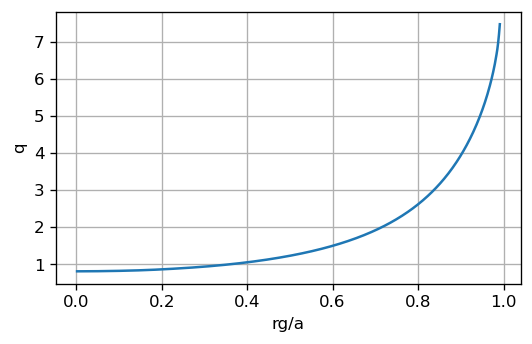

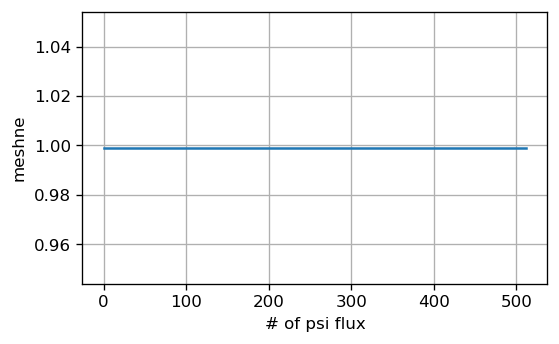

In [3]:
print(physical_parameters)
help(gtc.gridshow)
gtc.gridshow(radial_grid,3)
gtc.profileshow(radial_profile,6)

## equilibrium.out

In [4]:
(pdata,spdata)=Eq.read(case_path+"equilibrium.out")

Help on function spshow in module equilibrium:

spshow(pdata, spdata, kind=0, savefig=0)
    show 2D poloidal plots
    # kind
        0: poloidal mesh (default)
        1: B-field
        2: Jacobian
        3: i current
        4: zeta2psi
        5: delB
        6: B-field at outer boundary
        7: Jacobian at outer boundary
        8: error of spline
    # savefig
        0: don't save figure (default)
        1: save figure



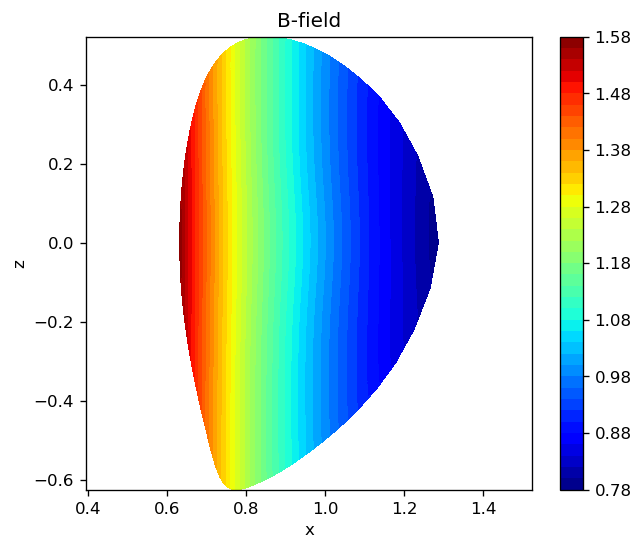

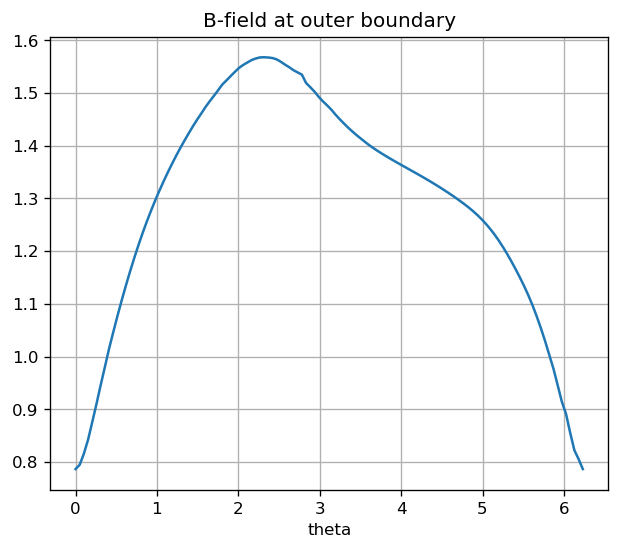

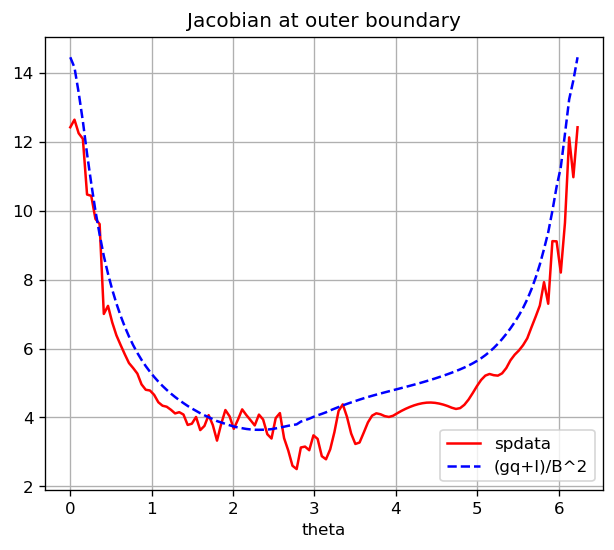

In [5]:
help(Eq.spshow)
Eq.spshow(pdata,spdata[:,:,:],1)
Eq.spshow(pdata,spdata[:,:,:],6)
Eq.spshow(pdata,spdata[:,:,:],7)

Help on function pshow in module equilibrium:

pshow(pdata, kind=2, savefig=0)
    show the 1D radial plots and radial points
    # kind
        0: minor -- psi
        1: major radius -- psi
        2: -d(ln(Te))/dr -- r
        3: Te -- psi
        4: -d(ln(ne))/dr -- r
        5: ne -- psi
        6: -d(ln(Ti))/dr -- r
        7: Ti -- psi
        8: -d(ln(ni))/dr -- r
        9: ni -- psi
       10: -d(ln(Tf))/dr -- r
       11: Tf -- psi
       12: -d(ln(nf))/dr -- r
       13: nf -- psi
       14: Zeff -- psi
       15: rotation -- psi
       16: Er -- psi
       17: q -- psi
       18: q -- r
       19: d q/d psi -- psi
       20: r -- psi
       21: g -- psi
       22: g -- r
       23: P -- psi
       24: P -- r
       25: toroidal flux -- psi
       26: toroidal flux -- r
       27: rg -- psi
       28: rg -- r
       29: d torpsi/d psi -- psi 
    # savefig
        0: don't save figure (default)
        1: save figure



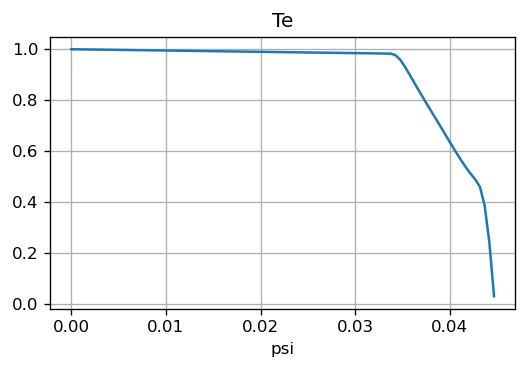

In [10]:
help(Eq.pshow)
Eq.pshow(pdata,3)

## history.out

In [6]:
(parthist,fieldhist,modehist,ndstep, nspecies, mpdiag, nfield, modes, mfdiag, tstep) = His.read(case_path+"history.out")

# tsteps # species # diagnostics # fields # modes # field quants tstep size
600 2 11 3 8 4 0.629332


Help on function particleshow in module history:

particleshow(parthist, pdiag=0, species=0, savefig=0)
    # nspecies
        0: ion (default)
        1: EP
        2: electron
    # pdiag
        0: deltaf (default)
        1: deltaf*deltaf
        2: angmon
        3: angmon*deltaf
        4: energy
        5: energy*deltaf
        6: (vdr+vap)*deltaf
        7: (vdr+vap)*angmon*deltaf
        8: (vdr+vap)*energy*deltaf
        9: real(iout)
        10: real(mp)
    # savefig
        0: don't save figure (default)
        1: save figure



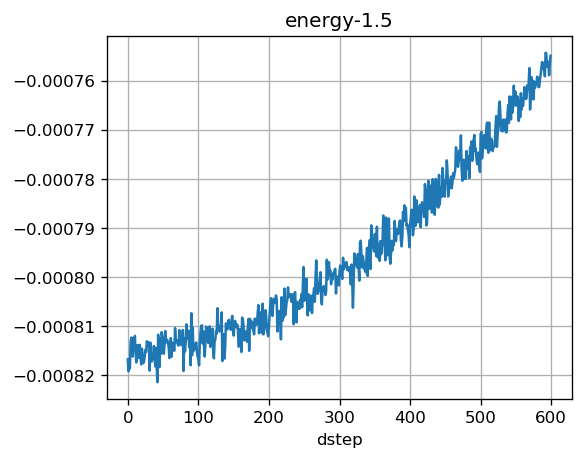

In [20]:
help(His.particleshow)
His.particleshow(parthist,4,0)

Help on function fieldshow in module history:

fieldshow(fieldhist, fdiag=0, nfield=0, savefig=0)
    # fdiag
        0: (theta=zeta=0) (default)
        1: 00
        2: ZF RMS
        3: RMS
    # nfield
        0: phi
        1: Apara
        2: fluidne
    # savefig
        0: don't save figure (default)
        1: save figure



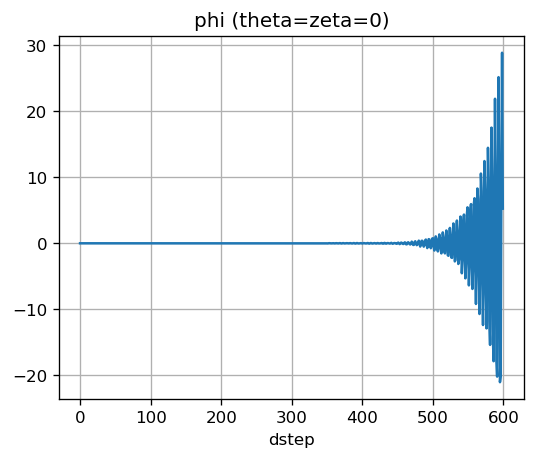

In [7]:
help(His.fieldshow)
His.fieldshow(fieldhist, fdiag=0, nfield=0, savefig=0)

Help on function modeshow in module history:

modeshow(modehist, mode_numb=[0], nfield=0, tstep=1, xmin=0, xmax=3, flagfft=1, savefig=0)
    # flagfft
        0: only keep frequency>0
        1: remain negative frequency
    # nfield
        0: phi
        1: Apara
        2: fluidne
    # savefig
        0: don't save figure (default)
        1: save figure

mode1  gamma= 0.035761089840385195
mode1  frequency= 3.0750400021154376
mode2  gamma= 0.0390719418836817
mode2  frequency= 3.055072209893909
mode3  gamma= 0.035562270677624935
mode3  frequency= -2.515941819912631
mode4  gamma= 0.03686344969131072
mode4  frequency= 3.055072209893909
mode5  gamma= 0.03711864360453664
mode5  frequency= 2.056682598817468
mode6  gamma= 0.03197666611032225
mode6  frequency= -1.9768114299313528
mode7  gamma= 0.04319694558788864
mode7  frequency= -1.9967792221528815
mode8  gamma= 0.04241662102316133
mode8  frequency= -2.0167470143744106


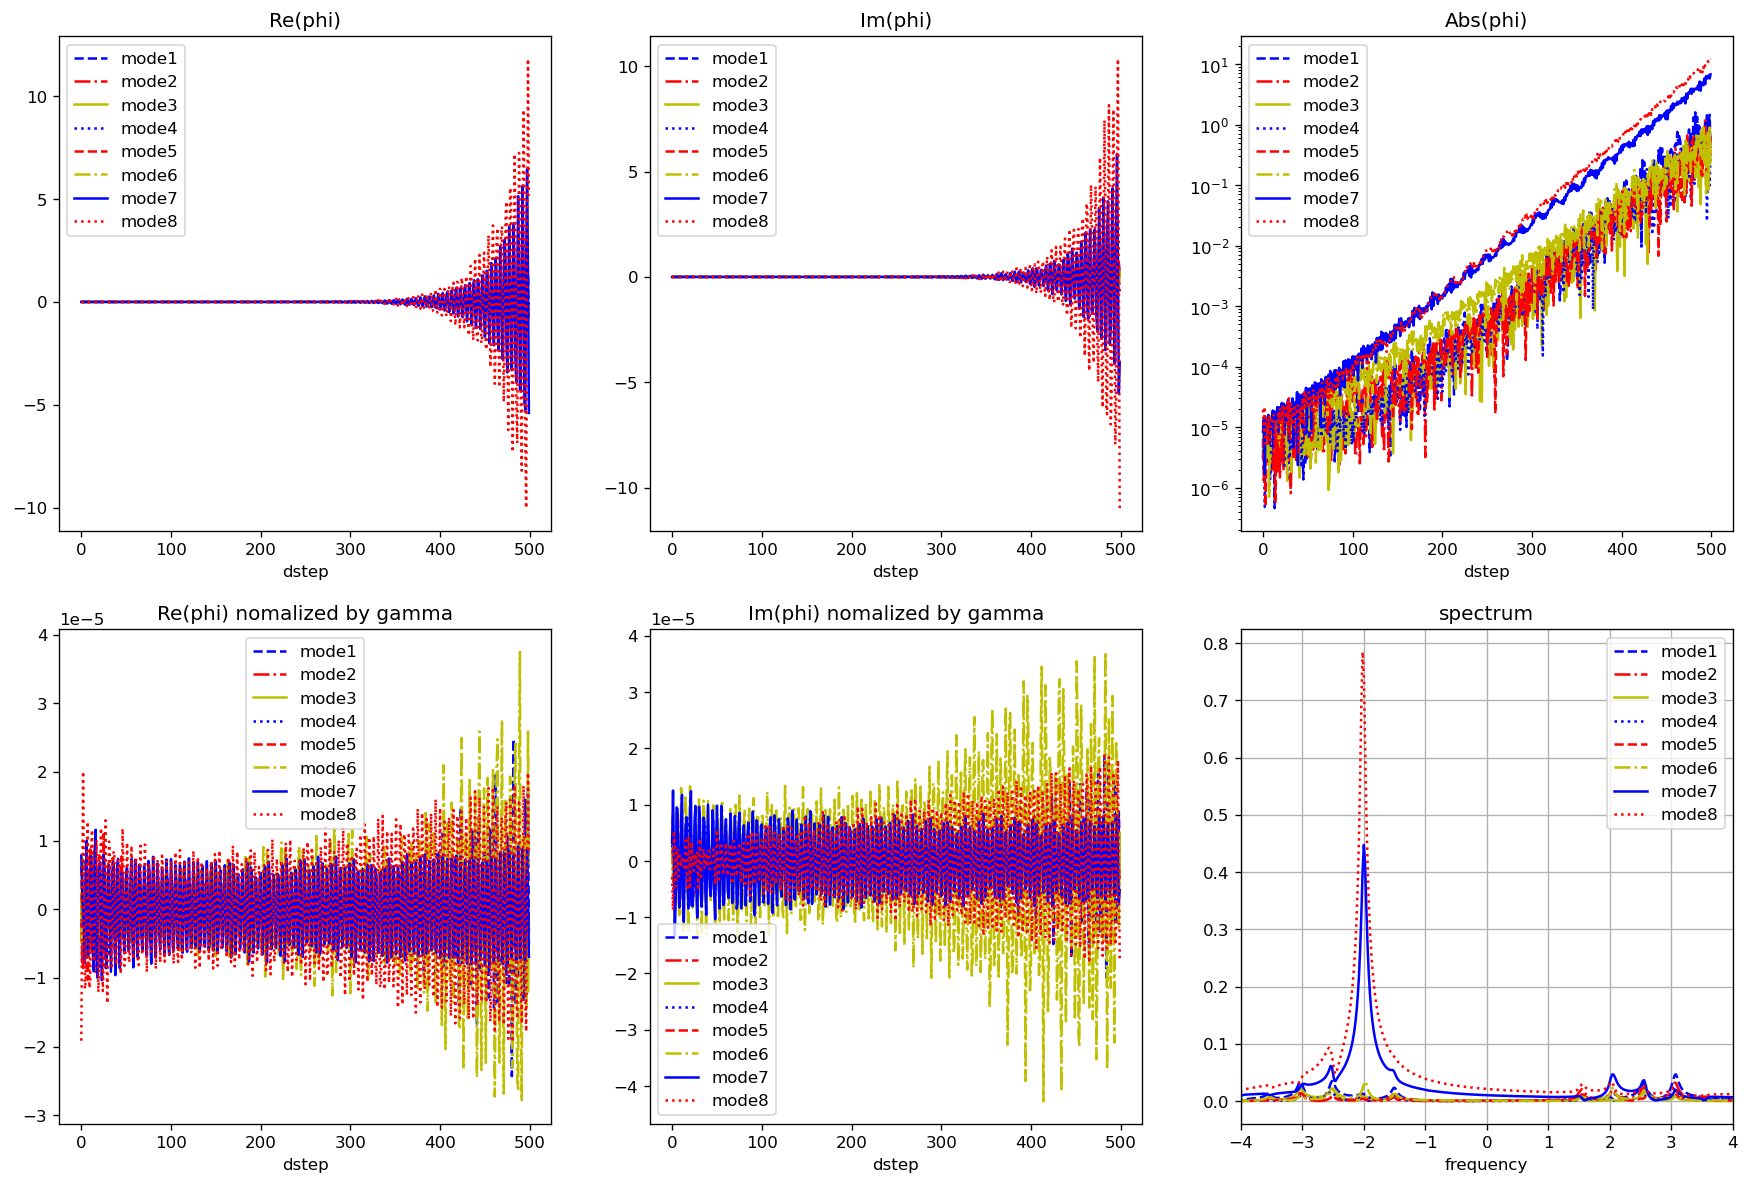

In [22]:
help(His.modeshow)
His.modeshow(modehist[100:600,:,:], [0,1,2,3,4,5,6,7], 0, tstep,0,4,1)

## snapshot.out

In [4]:
(profile, pdf, poloidata,fluxdata,pdf2ddata,nspecies,nfield,nvgrid,mpsi,mtgrid,mtoroidal,tmax) = Snap.read(case_path+"/snap0003000.out",0)

nspecies= 2 , nfield= 3 , nvgrid= 65 , mpsi= 101 , mtgrid= 181 , mtoroidal= 24 , tmax= 5.0


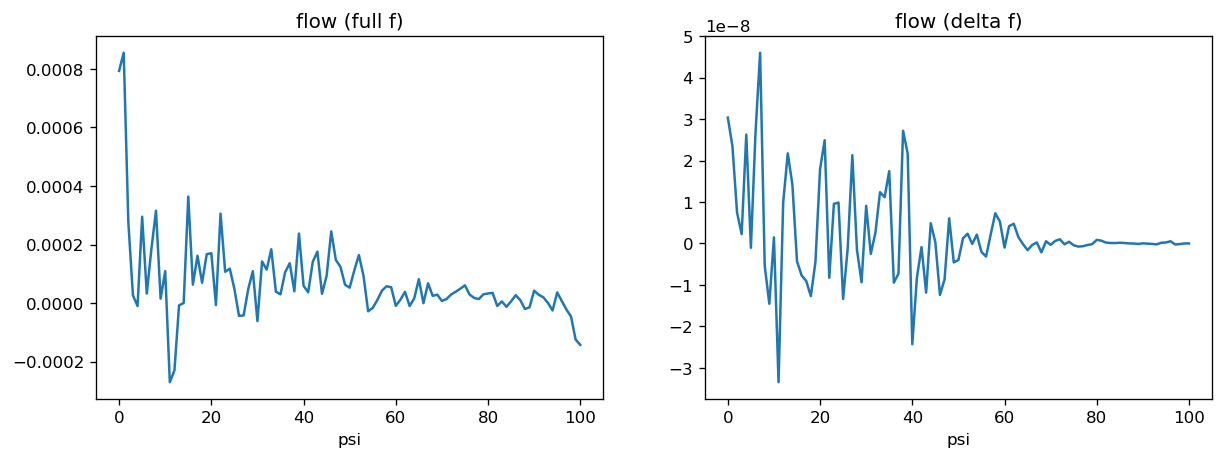

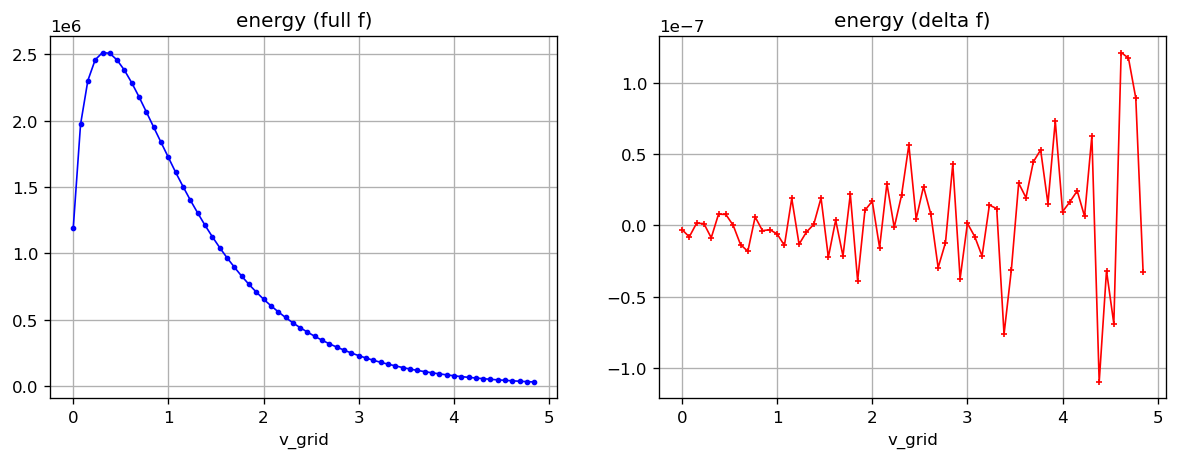

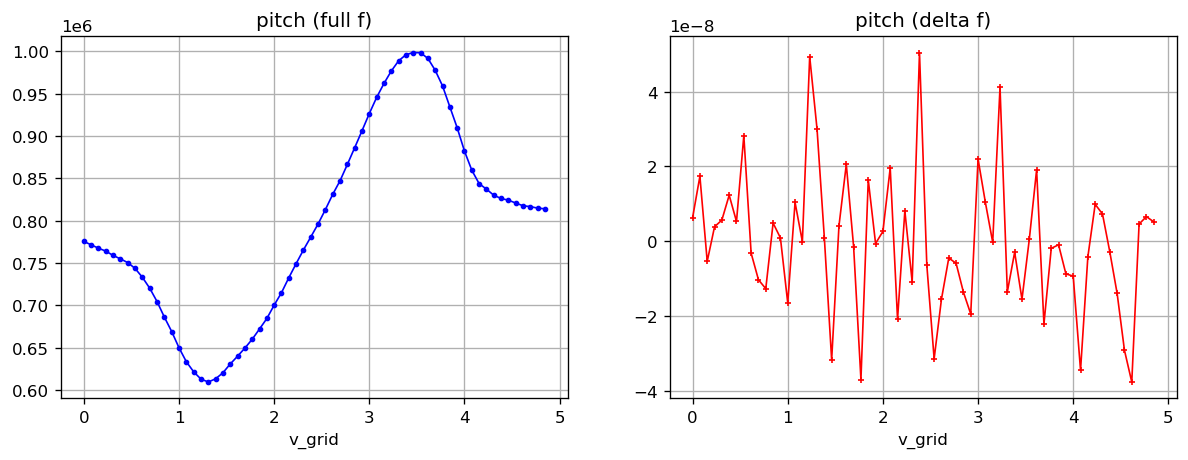

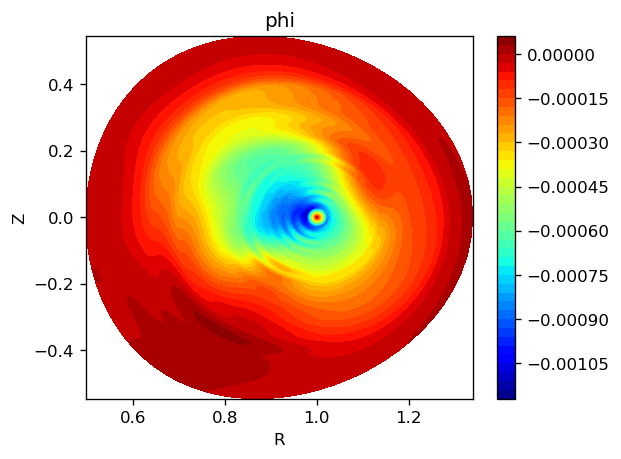

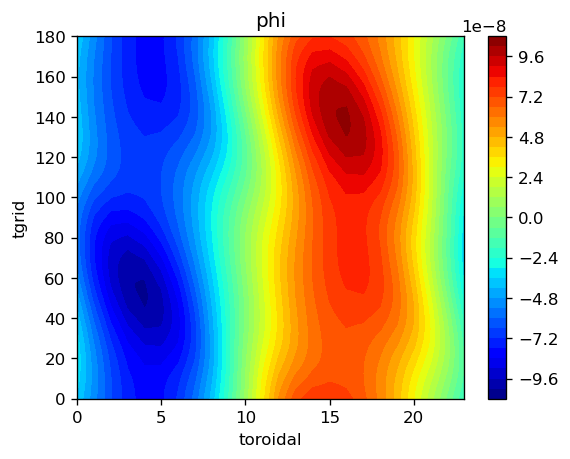

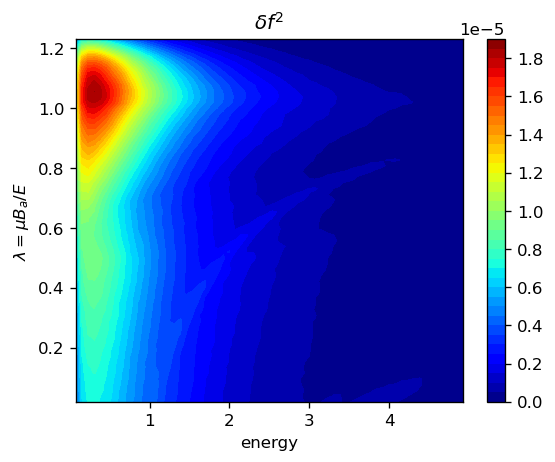

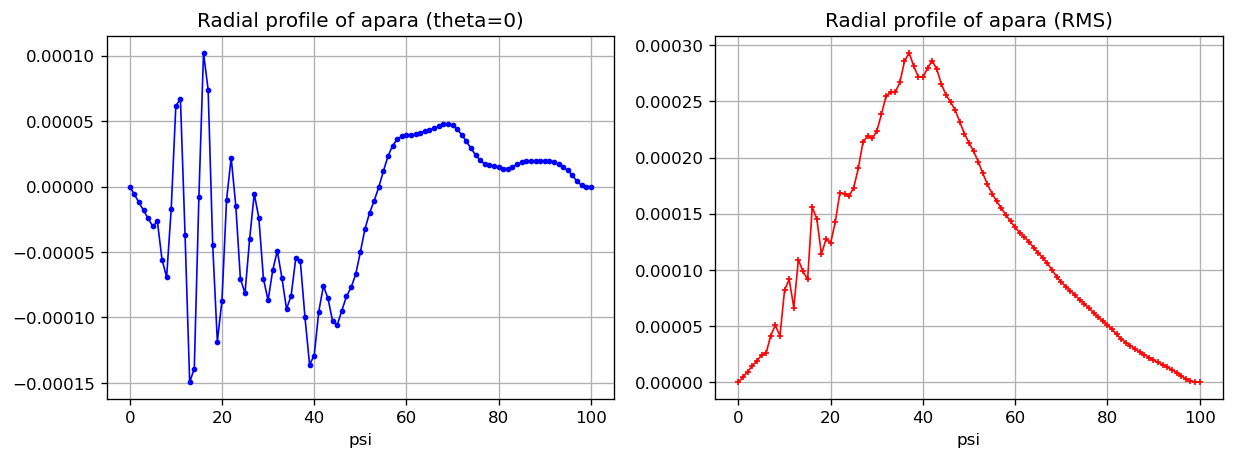

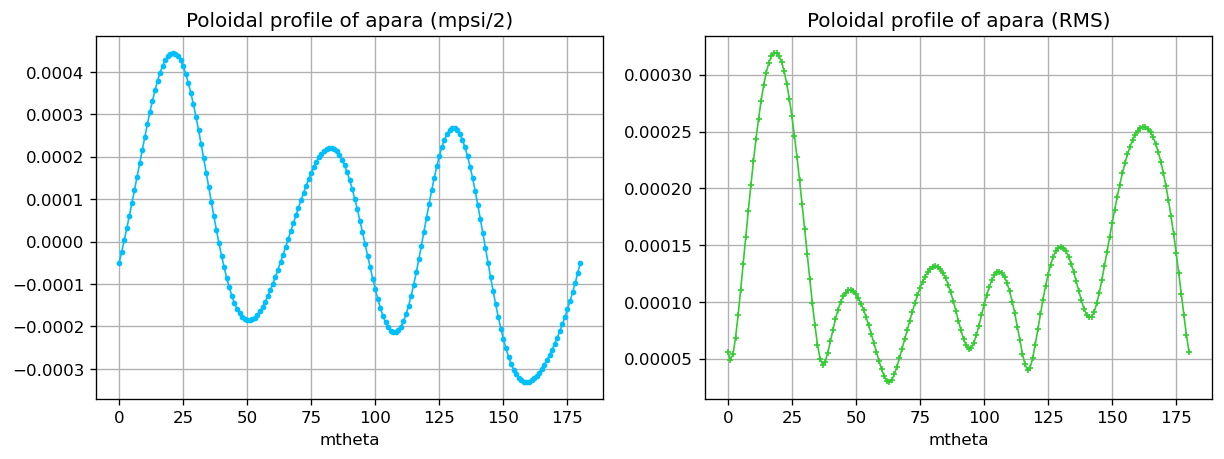

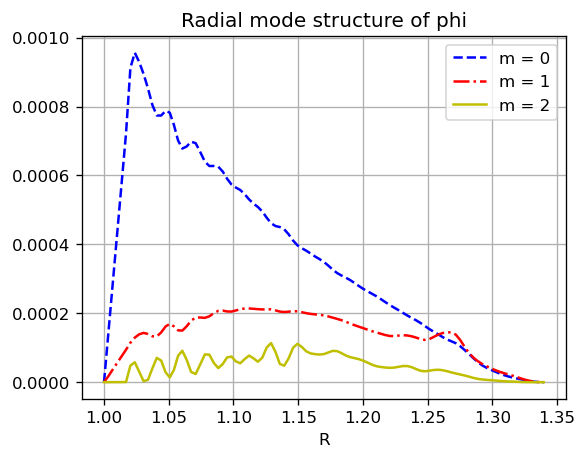

In [7]:
Snap.profileshow(profile, kind=1, nspecies=0, savefig=0)
Snap.pdfshow(pdf, tmax, kind=0, nspecies=1, savefig=0)
Snap.pdfshow(pdf, tmax, kind=1, nspecies=1, savefig=0)
Snap.poloishow(poloidata,1)
Snap.fluxshow(fluxdata,1)
Snap.pdf2dshow(pdf2ddata,2,1)
Snap.poloipsi(poloidata, mpsi, mtgrid, 1)
Snap.poloitheta(poloidata, mpsi, mtgrid, 1)
Snap.poloiRm(poloidata,0,2)

## data1d.out

In [34]:
(data1di,data1df,data1de,field00,fieldrms)=data1d.read(case_path+"data1d.out")

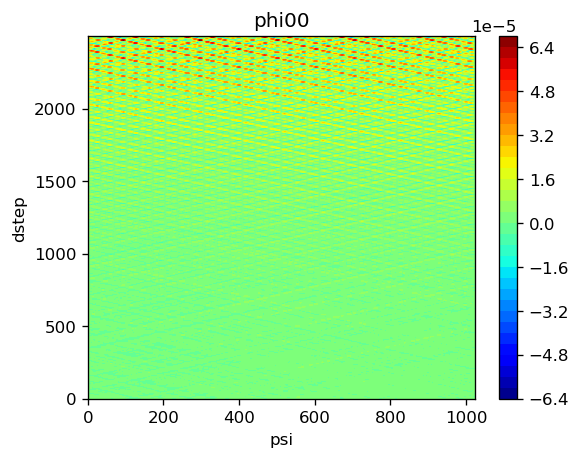

In [35]:
data1d.fieldshow(field00[500:3000,:,:],0,0,0)

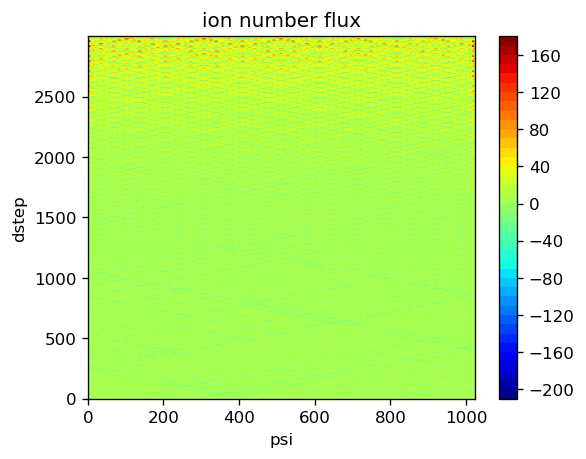

In [37]:
data1d.particleshow(data1di, particletype = 0, kind = 0, savefig = 0)